# Cellular Automata

[Moreno Marzolla](https://www.moreno.marzolla.name)

Written in June 2026.

Last modified June 2026.

---

Example: rule 30


In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['image.cmap'] = 'binary'
plt.rcParams['figure.dpi'] = 300
import numpy as np
rng = np.random.RandomState(42)

def rule(r):
    '''
    Given an integer 0 <= r < 256, return an array of length 8
    with the new states according to Wolfram numbering.
    '''
    result = np.zeros(8, int)
    idx = 0
    while (r > 0):
        result[idx] = (r & 1)
        idx = idx + 1
        r = r >> 1
    return result

print(rule(30))

[0 1 1 1 1 0 0 0]


In [2]:
def evolve(state, rule):
    '''
    Given the current state (array of length n) and the rule array (array of length 8), return
    the next state.
    '''
    L = np.roll(state,1)  # left
    C = state             # center
    R = np.roll(state,-1) # right
    result = np.zeros(len(state),int)
    for i in range(0,len(state)):
        result[i] = rule[L[i]*4 + C[i]*2 + R[i]]
    return result

print(evolve([0,0,0,1,0,0,0,0], rule(30)))

[0 0 1 1 1 0 0 0]


In [3]:
def CA(r, initial_state, n):
    '''
    Return a matrix of n rows with the evolution of
    rule-r CA starting from state `initial_State`.
    Cyclic boundary conditions are assumed.
    '''
    width = len(initial_state)
    result = np.zeros([n,width], int)
    result[0,:] = initial_state
    rr = rule(r)
    for i in range(1,n):
        result[i,:] = evolve(result[i-1,:],rr)
    return result

CA(30, [0, 0, 0, 1, 0, 0, 0, 0], 5)

array([[0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 1, 1, 1, 0, 0, 0],
       [0, 1, 1, 0, 0, 1, 0, 0],
       [1, 1, 0, 1, 1, 1, 1, 0],
       [1, 0, 0, 1, 0, 0, 0, 0]])

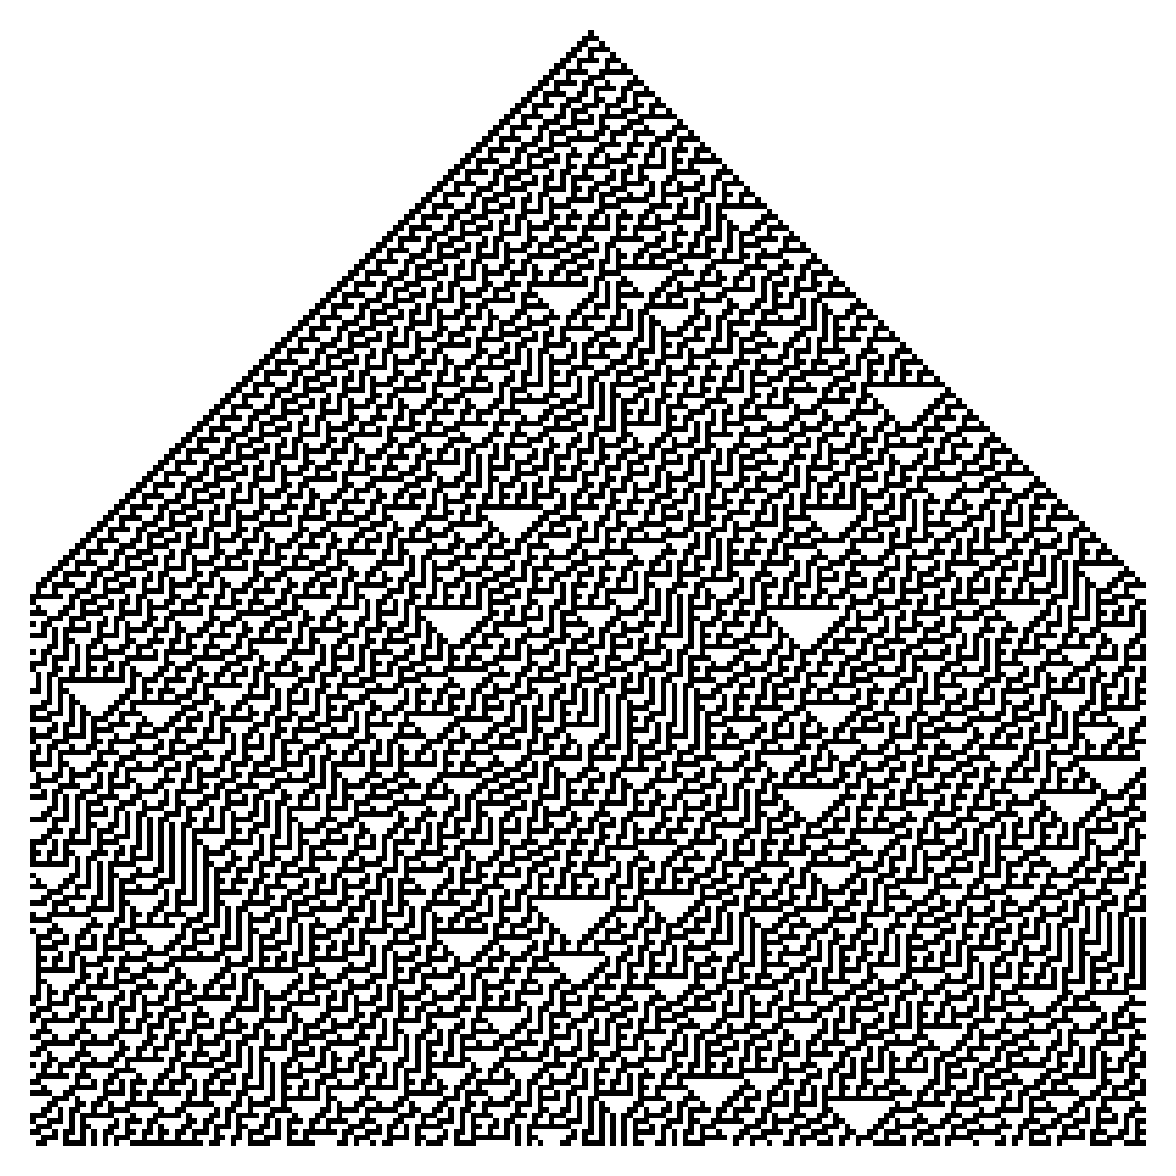

In [4]:
n = 200
initial_state = np.zeros(n)
initial_state[n//2] = 1
plt.matshow(CA(30, initial_state, n))
plt.axis(False)
plt.show()

In [5]:
def plot_CA_class(rule_list, class_label):
    '''
    Source: https://matplotlib.org/matplotblog/posts/elementary-cellular-automata/
    '''
    #rng = np.random.RandomState(seed=0)
    fig, axs = plt.subplots(1, len(rule_list),figsize=(10, 3.5), constrained_layout=True)
    initial = rng.randint(0, 2, 100)

    for i, ax in enumerate(axs.ravel()):
        data = CA(rule_list[i], initial, 100)
        ax.set_title(f'Rule {rule_list[i]}')
        ax.matshow(data)
        ax.axis(False)

    fig.suptitle(class_label, fontsize=16)

    return fig, ax

## Class One

CA that converge towards a uniform state (i.e., a _fixed point_).

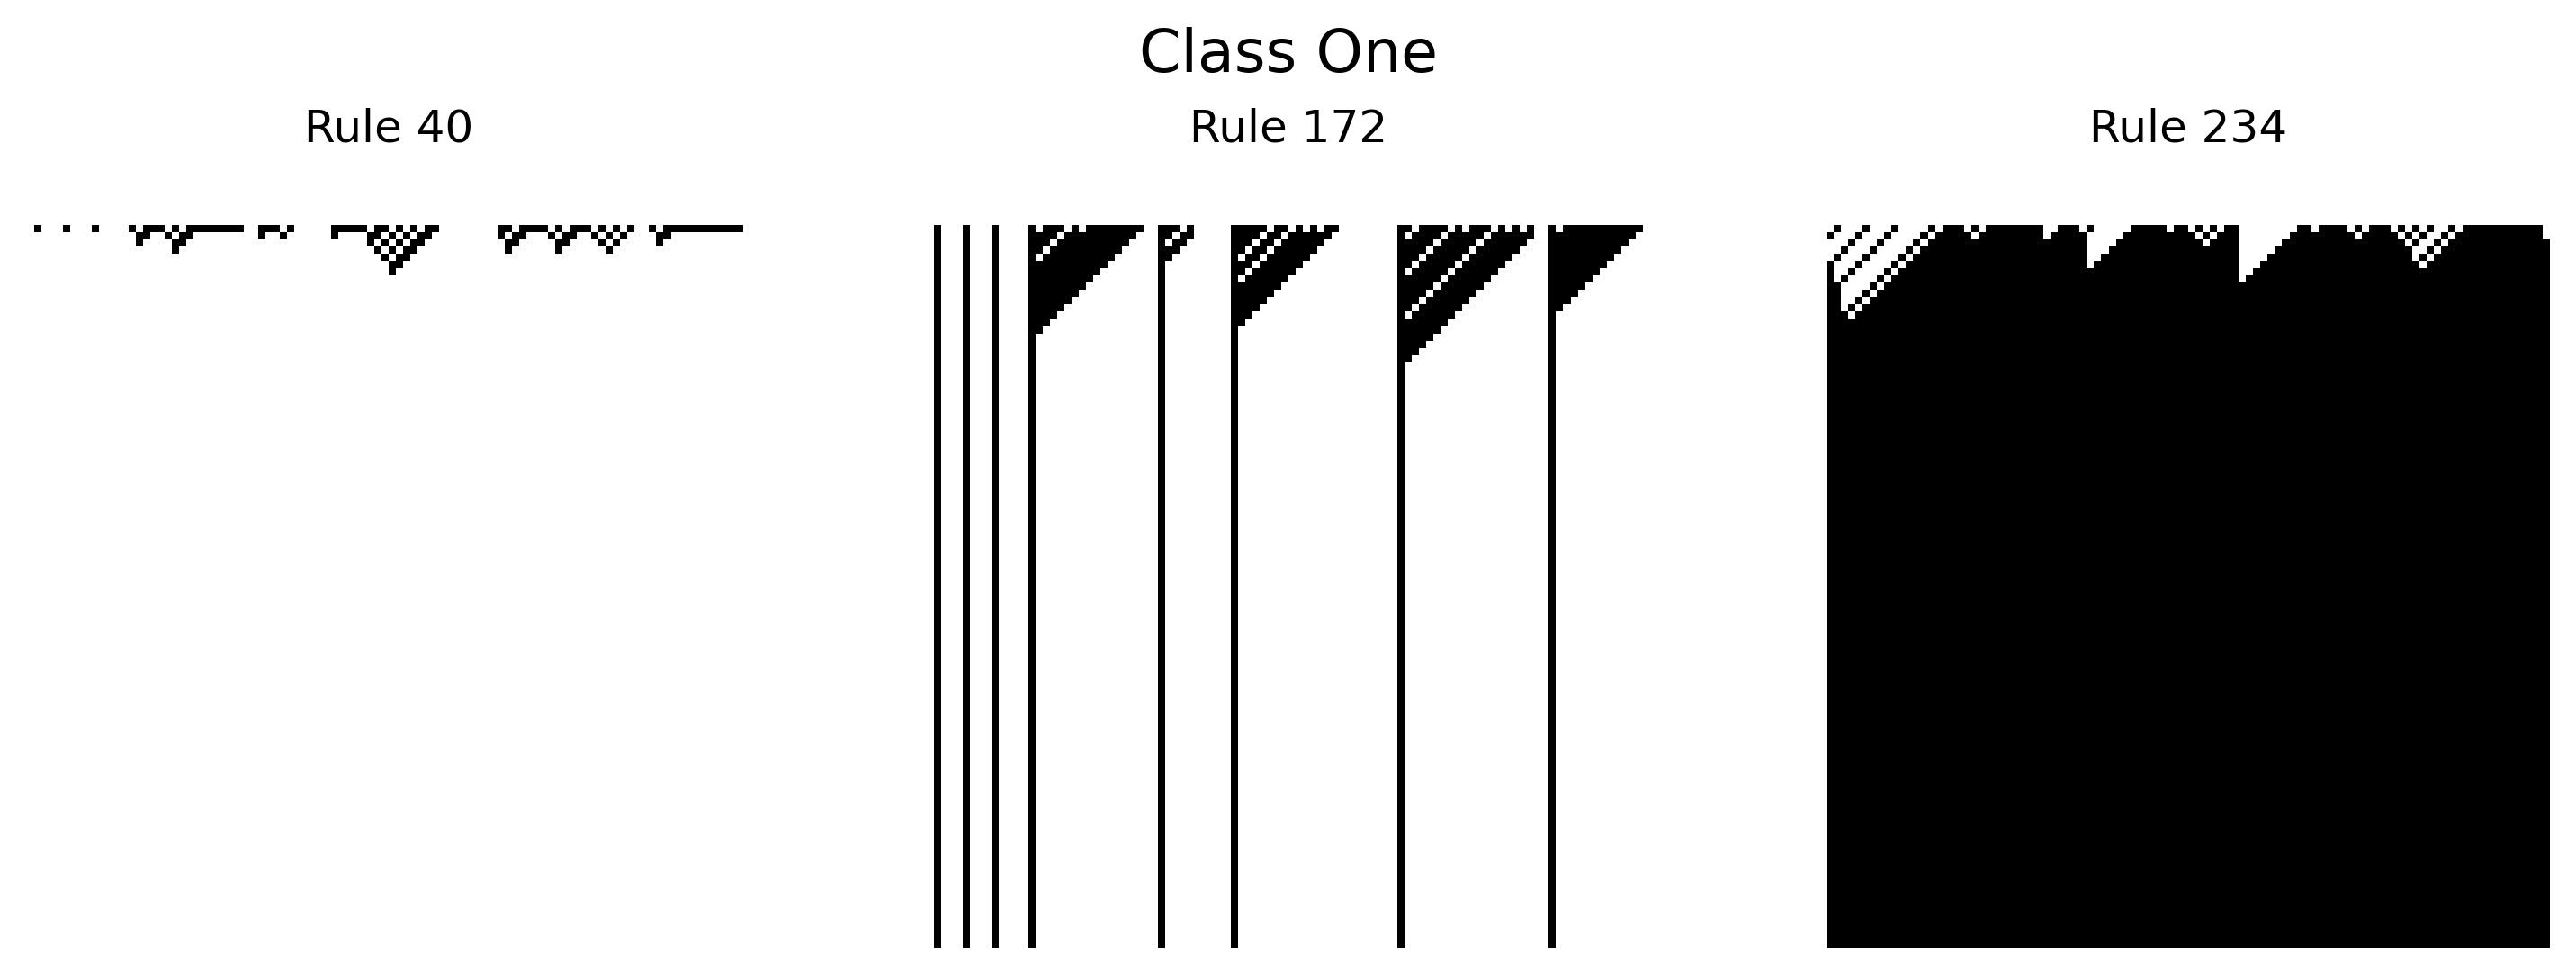

In [6]:
_ = plot_CA_class([40, 172, 234], 'Class One')

## Class Two

Cellular automata which rapidly converge to a repetitive or stable state (i.e., _periodic orbit_).

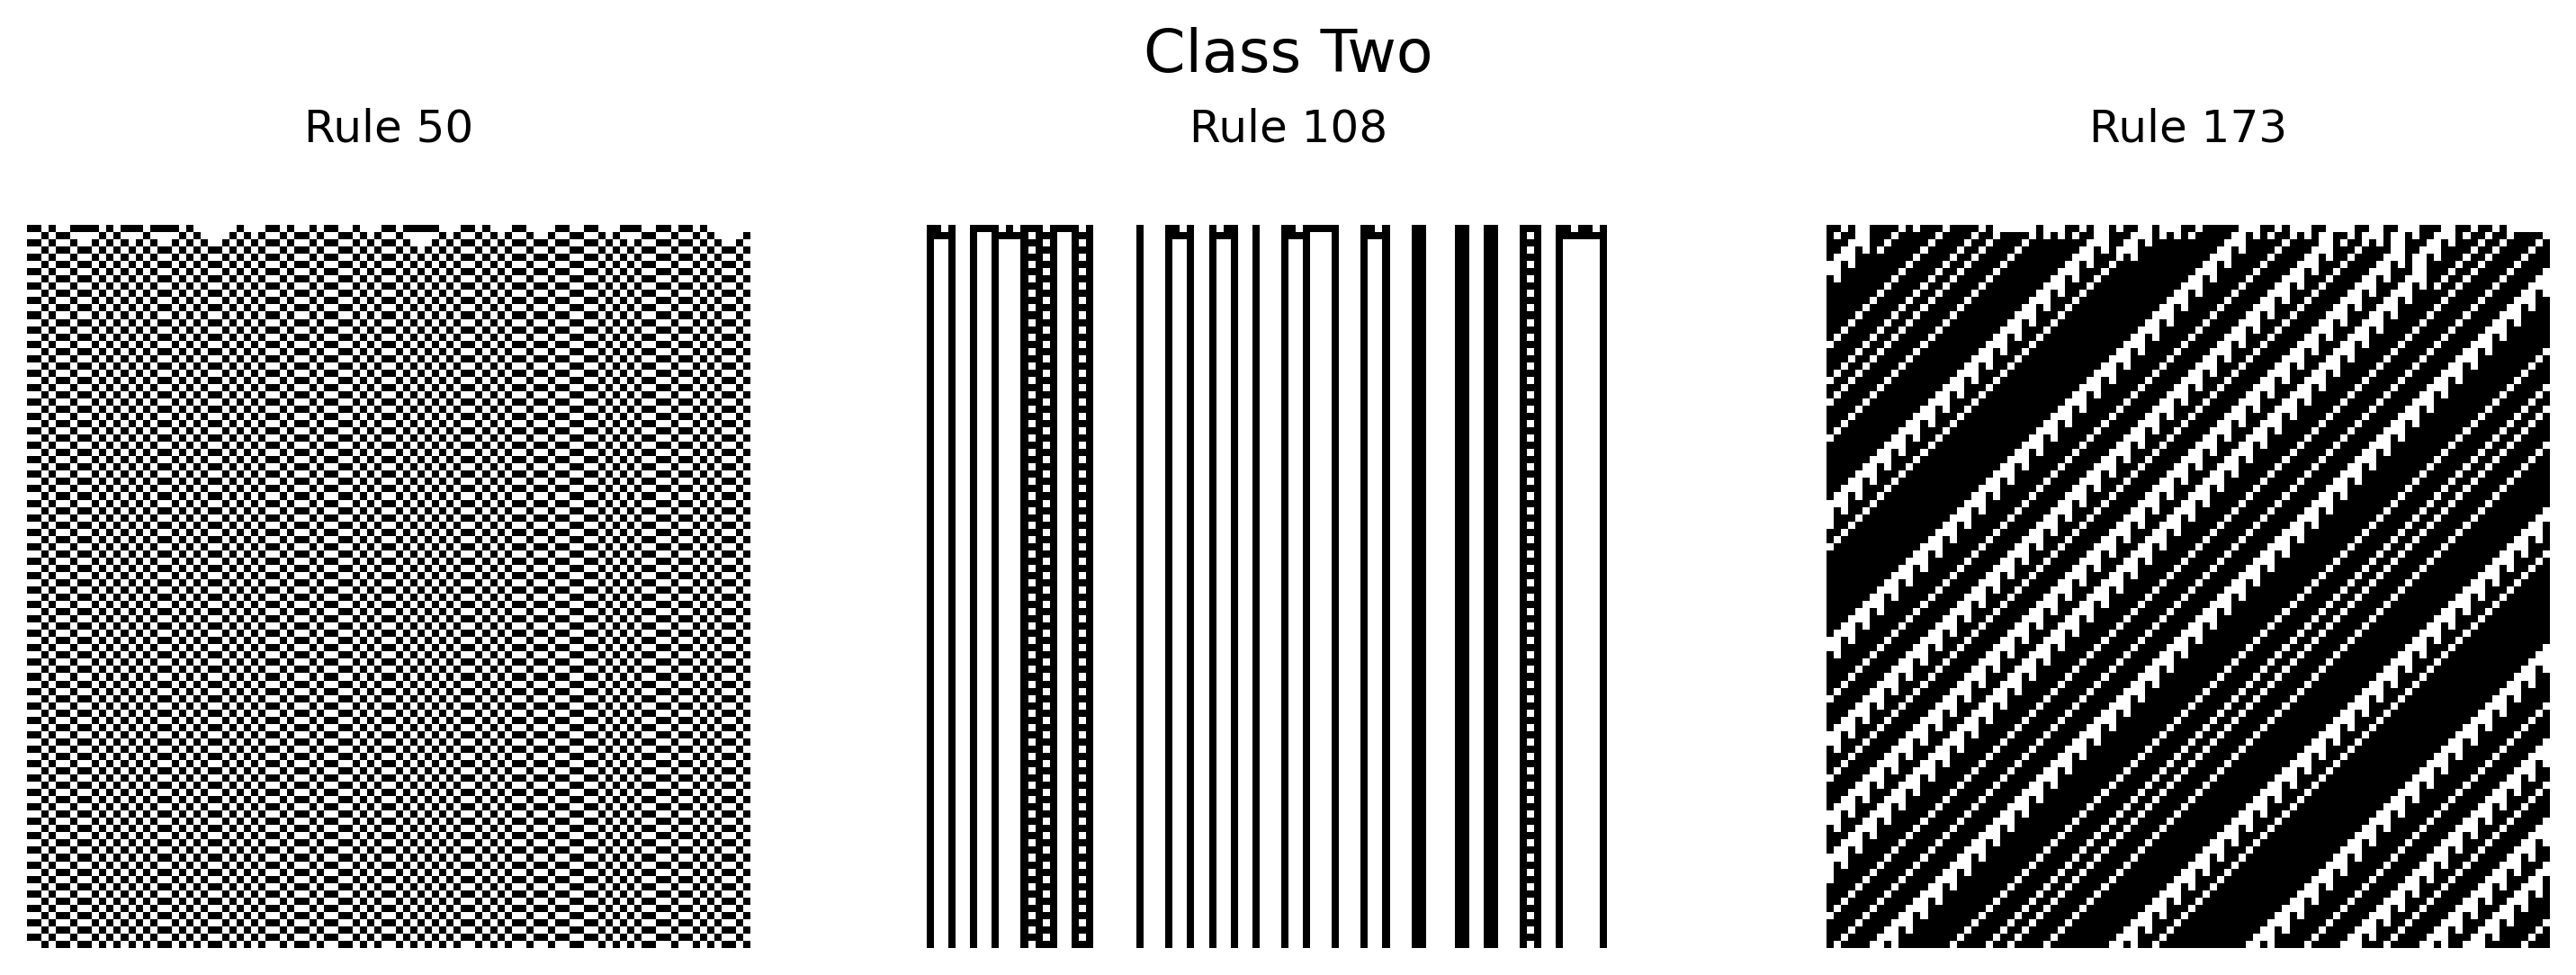

In [13]:
_ = plot_CA_class([50, 108, 173], 'Class Two')

## Class Three

Cellular automata which appear to remain in a random state.

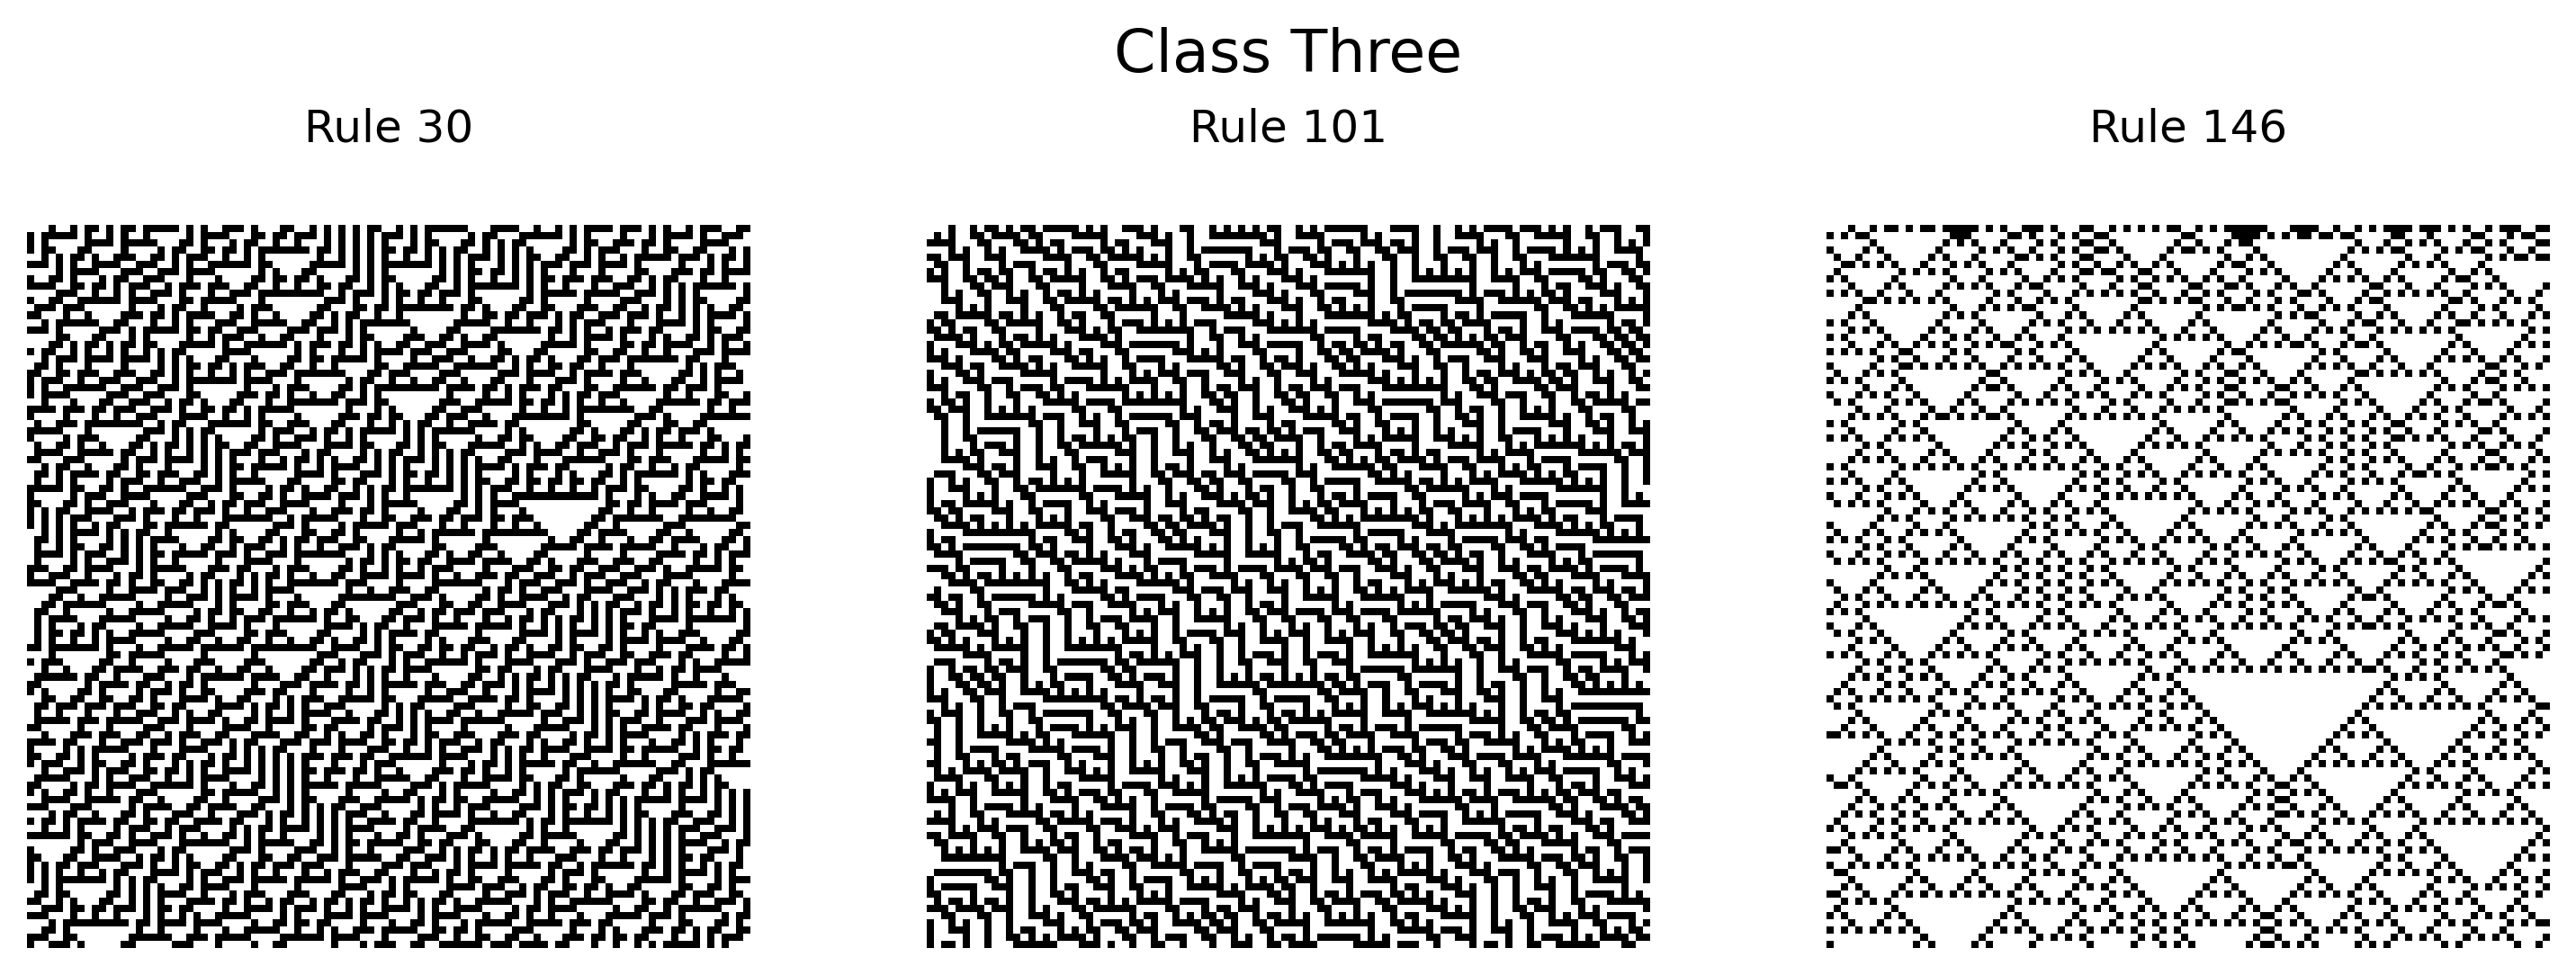

In [11]:
_ = plot_CA_class([30, 101, 146], 'Class Three')

## Class Four

Cellular automata which form areas of repetitive or stable states, but also form structures that interact with each other in complicated ways.

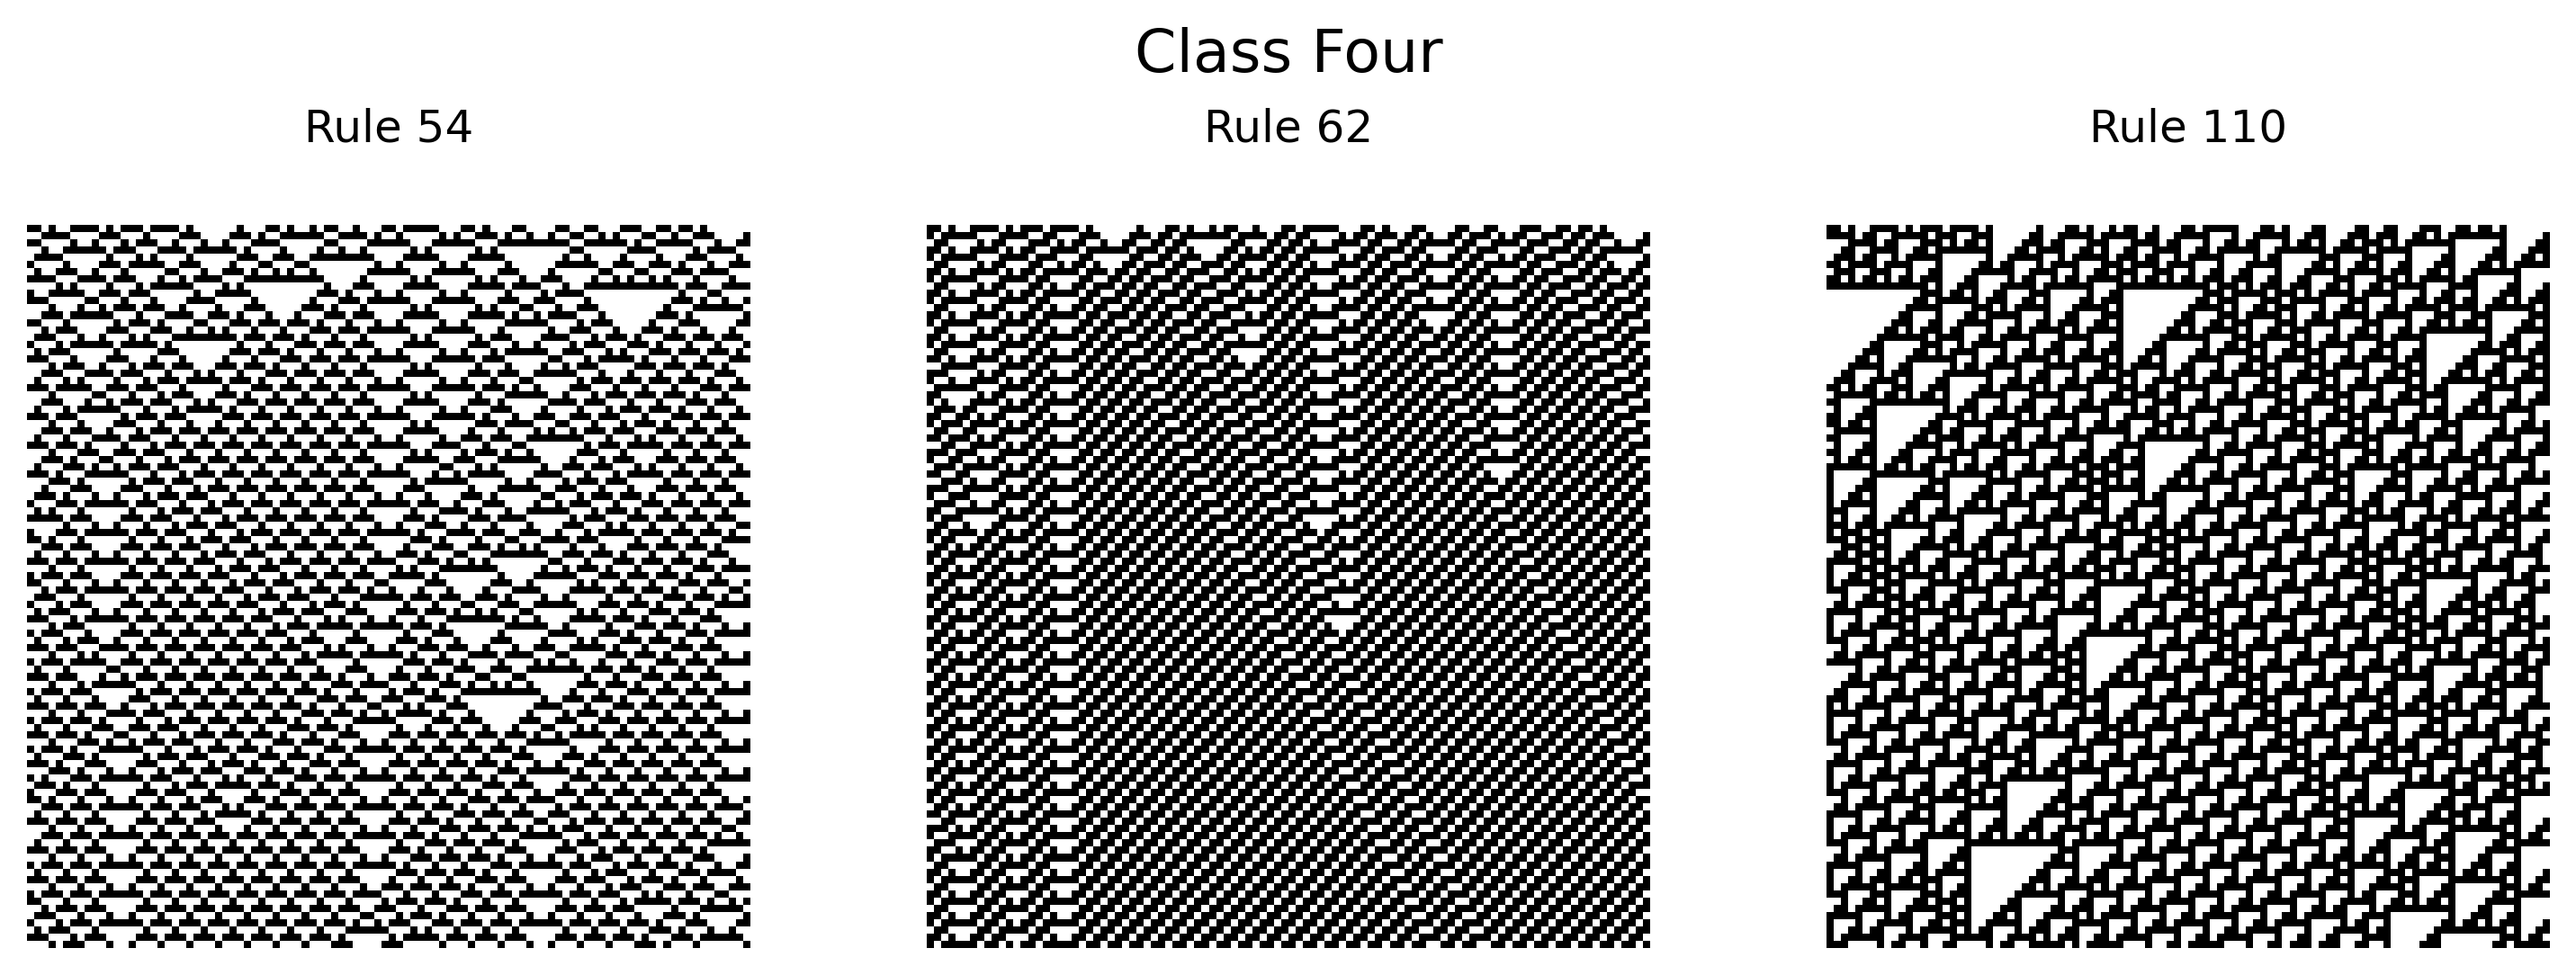

In [14]:
_ = plot_CA_class([54, 62, 110], 'Class Four')

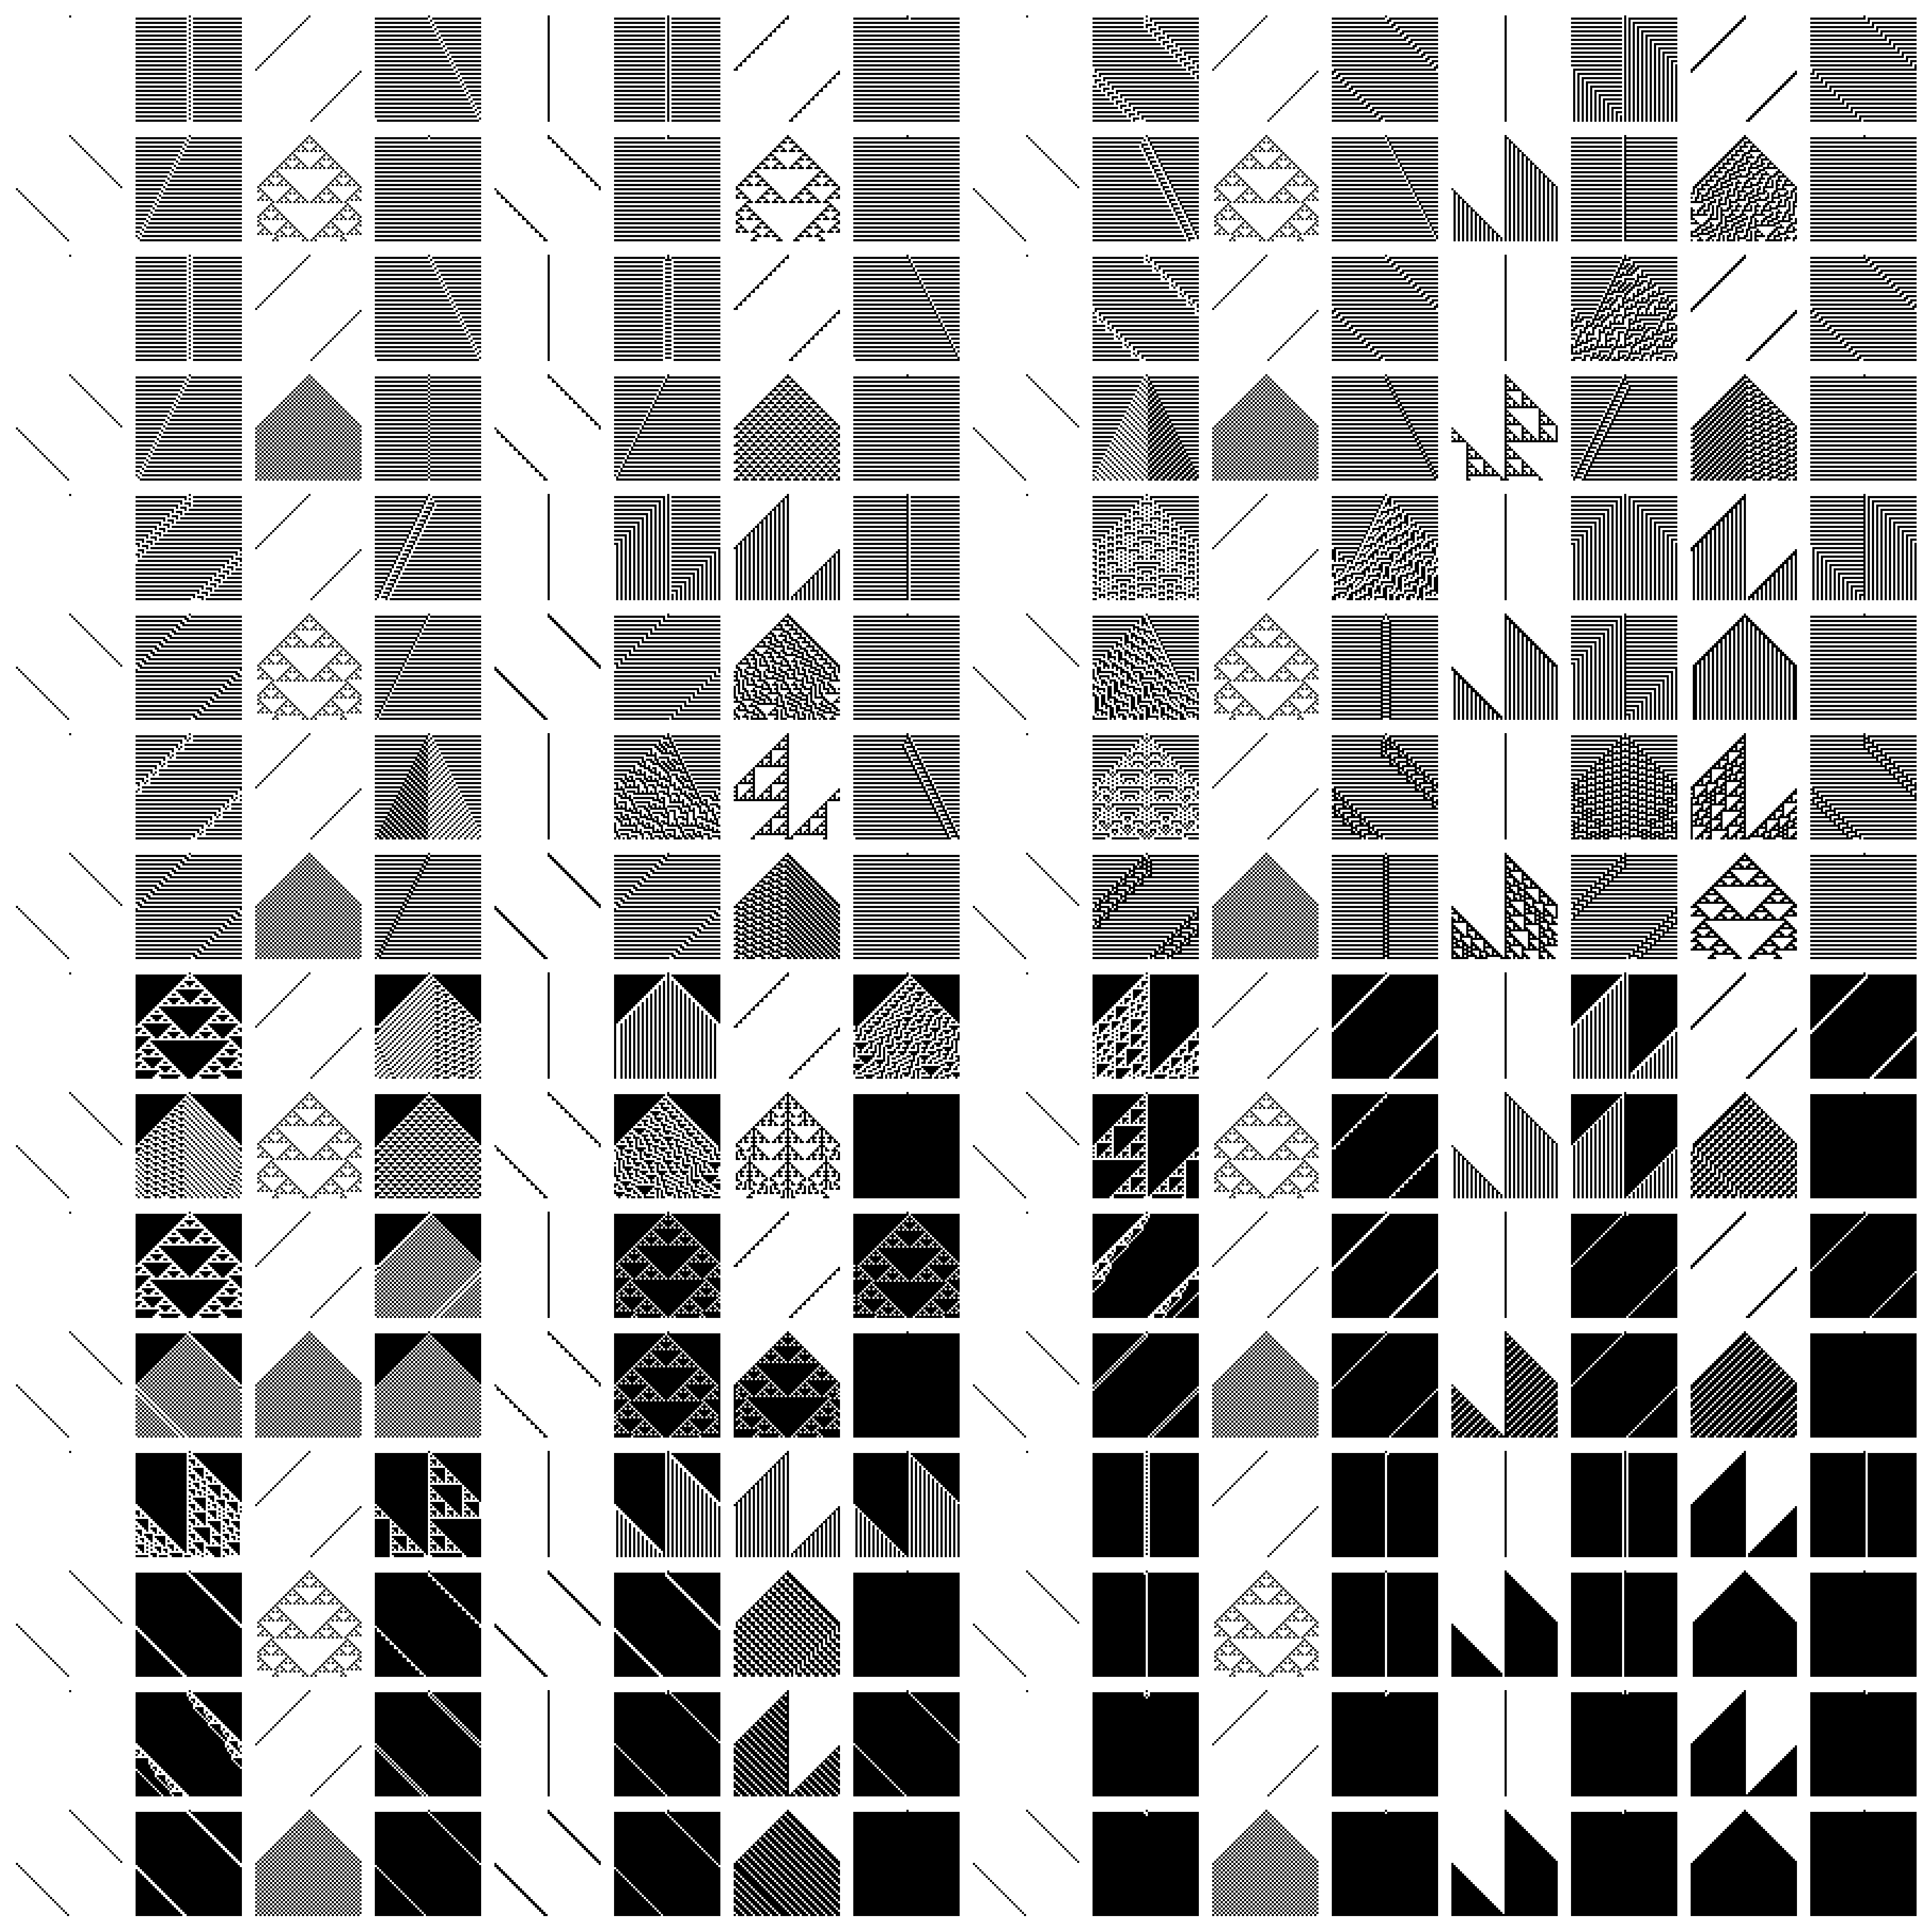

In [17]:
# Gallery of CA
n = 50
initial_state = np.zeros(n, int)
initial_state[n//2] = 1
#initial_state = rng.randint(0,2,n)
plt.subplots(16,16,figsize=(12,12), sharex=True, sharey=True, constrained_layout=True)
for i in range(0,16):
    for j in range(0,16):
        r = i*16+j
        ax = plt.subplot(16,16,r+1)
        ax.axis(False)
        ax.matshow(CA(r, initial_state, n))
plt.show()

## References

- Eitan Lees, <https://matplotlib.org/matplotblog/posts/elementary-cellular-automata/>